## Price Elasticity Model


### Import necessary library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


### Load the Dataset

In [3]:
fitness_data = pd.read_excel("Cleaned_Preprocessed_Dataset_Yogeshwar Tribhuvan.xlsx")

### Dataset Information


In [4]:
fitness_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
dtypes: datetime64[us](2), int64(3), str(2)
memory usage: 258.3 KB


In [5]:
fitness_data["ActivityDescription"].unique()

<ArrowStringArray>
[  '20-20-20  2.45pm-3.45pm',      '20-20-20 7.00-8.00pm',
     '20-20-20 9.30-10.30am',        '20:20:20  10-11 Am',
   '20:20:20  10.00-11.00am',    '20:20:20  11am -12noon',
    '20:20:20  9.30-10.30am',     '20:20:20 9.30-10.30am',
   '45min Madness 9.15-10am',     '5.30-6.30pm Body Cond',
 ...
   'Studio Cyc 9.05 -9.55am',      'B L T Antenatal Mums',
         'B L T Chair Based',     'Body Cond 5.45-6.45pm',
       'Body Cond 1745-1845',   'Purestretch 6.45-7.45pm',
  'Family Bootcamp 4-4.45pm',     'Wm Better Living Team',
 'B L T- Weight Manage Clas', 'Strokeskill 19.15-20.15pm']
Length: 280, dtype: str

In [6]:
fitness_data.describe()

,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
count,3289,3289,3289.000000,3289.000000,3289.000000
mean,2018-05-16 08:58:57.610215,1900-01-01 13:38:29.425358,32.179386,17.088781,1850.231377
min,2018-04-01 00:00:00,1900-01-01 06:30:00,2.000000,1.000000,499.000000
25%,2018-04-24 00:00:00,1900-01-01 10:00:00,24.000000,10.000000,1299.000000
50%,2018-05-16 00:00:00,1900-01-01 12:30:00,30.000000,16.000000,1499.000000
75%,2018-06-08 00:00:00,1900-01-01 17:45:00,35.000000,24.000000,2499.000000
max,2018-06-30 00:00:00,1900-01-01 20:15:00,70.000000,64.000000,3999.000000
std,NaN,NaN,15.092156,9.504098,791.207290


In [7]:
fitness_data.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499


### Create New Feature

In [8]:
fitness_data["Month"] = fitness_data["BookingEndDate"].dt.month
fitness_data["Hour"] = fitness_data["BookingStartTime"].dt.hour
fitness_data["DayOfWeek"] = fitness_data["BookingEndDate"].dt.dayofweek
fitness_data["DayName"] = fitness_data["BookingEndDate"].dt.day_name()
fitness_data["IsWeekend"] = fitness_data["DayOfWeek"].isin([5, 6]).astype(int)

In [9]:
def session(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

fitness_data["Session"] = fitness_data["Hour"].apply(session)

In [10]:
def capacity_category(x):
    if x <= 20:
        return "Small"
    elif x <= 40:
        return "Medium"
    else:
        return "Large"

fitness_data["CapacityCategory"] = fitness_data["MaxBookees"].apply(capacity_category)

In [11]:
def price_category(x):
    if x <= 600:
        return "Low"
    elif x <= 1200:
        return "Medium"
    else:
        return "High"

fitness_data["PriceCategory"] = fitness_data["Price (INR)"].apply(price_category)

In [12]:
fitness_data.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Month,Hour,DayOfWeek,DayName,IsWeekend,Session,CapacityCategory,PriceCategory
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499,4,14,6,Sunday,1,Afternoon,Medium,Low
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499,4,14,6,Sunday,1,Afternoon,Medium,Low
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499,4,14,6,Sunday,1,Afternoon,Medium,Low
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499,4,14,6,Sunday,1,Afternoon,Medium,Low
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499,5,14,6,Sunday,1,Afternoon,Medium,Low


In [13]:
fitness_data = pd.get_dummies(
    fitness_data,
    columns=[
        "ActivitySiteID",
        "ActivityDescription",
        "Month",
        "Session",
        "DayName"
    ],
    drop_first=True
)

### Encode Categorical Features

In [14]:
fitness_data.head()

,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Hour,DayOfWeek,IsWeekend,CapacityCategory,PriceCategory,...,Month_5,Month_6,Session_Evening,Session_Morning,DayName_Monday,DayName_Saturday,DayName_Sunday,DayName_Thursday,DayName_Tuesday,DayName_Wednesday
0,2018-04-08,1900-01-01 14:45:00,25,12,499,14,6,1,Medium,Low,...,False,False,False,False,False,False,True,False,False,False
1,2018-04-15,1900-01-01 14:45:00,25,15,499,14,6,1,Medium,Low,...,False,False,False,False,False,False,True,False,False,False
2,2018-04-22,1900-01-01 14:45:00,25,14,499,14,6,1,Medium,Low,...,False,False,False,False,False,False,True,False,False,False
3,2018-04-29,1900-01-01 14:45:00,25,9,499,14,6,1,Medium,Low,...,False,False,False,False,False,False,True,False,False,False
4,2018-05-06,1900-01-01 14:45:00,25,7,499,14,6,1,Medium,Low,...,True,False,False,False,False,False,True,False,False,False


### Define Features and Target

In [15]:
X = fitness_data.drop(
    ["Number Booked","DayOfWeek", "BookingEndDate","CapacityCategory",
    "PriceCategory", "BookingStartTime","IsWeekend"],
    axis=1
)

y = fitness_data["Number Booked"]

In [16]:
print(X.columns.tolist())

['MaxBookees', 'Price (INR)', 'Hour', 'ActivitySiteID_HXP', 'ActivitySiteID_NBL', 'ActivitySiteID_SBP', 'ActivitySiteID_TSC', 'ActivityDescription_20-20-20 7.00-8.00pm', 'ActivityDescription_20-20-20 9.30-10.30am', 'ActivityDescription_20:20:20  10-11 Am', 'ActivityDescription_20:20:20  10.00-11.00am', 'ActivityDescription_20:20:20  11am -12noon', 'ActivityDescription_20:20:20  9.30-10.30am', 'ActivityDescription_20:20:20 9.30-10.30am', 'ActivityDescription_45min Madness 9.15-10am', 'ActivityDescription_5.30-6.30pm Body Cond', 'ActivityDescription_6.30-7.30pm Combat Aero', 'ActivityDescription_Abs Blast 7.45-8.15am', 'ActivityDescription_Aerobics', 'ActivityDescription_Aerobics 6.00-7.00pm', 'ActivityDescription_Aqua Babies 12 -12.30am', 'ActivityDescription_Aqua Babies 9.30-10.00am', 'ActivityDescription_Aqua Fit 11.15-12.00', 'ActivityDescription_Aqua Fit 12.15 -13.15', 'ActivityDescription_Aqua Fit 12.15-13.00', 'ActivityDescription_Aqua Fit 14.45pm', 'ActivityDescription_Aqua Fit 2

### Split the Dataset


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Check Dataset Shape

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2631, 296)
(658, 296)
(2631,)
(658,)


### Import Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

### Create the Model

In [20]:
# Linear Regression
lr_model = LinearRegression()

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

### Train the Model


In [21]:
# Train Models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Make Predictions

In [22]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [23]:
print(y_pred_lr[:10])
print(y_pred_rf[:10])

[ 6.24556414  9.52399278  8.23063415  9.32081571  7.11521681 25.97417591
 27.09855258  8.45116304  3.64397783  4.09467697]
[ 7.01765476  7.99878571  9.7913676   8.30197817  6.75712897 24.9463631
 29.32781548  7.64605952  1.32636905  6.18607341]


### Import Evaluation Metrics

In [24]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

### Calculate Model Performance

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Linear Regression")
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("\nRandom Forest")
print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression
R²: 0.7520894346446438
MAE: 3.036543838641015
RMSE: 4.566606833091677

Random Forest
R²: 0.7926965342692667
MAE: 2.96626644788005
RMSE: 4.175893226660837


### Model Comparison

In [26]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

comparison

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.752089,3.036544,4.566607
1,Random Forest,0.792697,2.966266,4.175893


In [27]:
from sklearn.model_selection import RandomizedSearchCV
# Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [28]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best Cross Validation Score:
0.8141366385389688


In [29]:
best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Random Forest After Hyperparameter Tuning")

print("R² Score :", r2_score(y_test, y_pred_best))
print("MAE      :", mean_absolute_error(y_test, y_pred_best))
print("MSE      :", mean_squared_error(y_test, y_pred_best))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_best)))

Random Forest After Hyperparameter Tuning
R² Score : 0.8109831721469634
MAE      : 2.8644573726256866
MSE      : 15.899837252356008
RMSE     : 3.9874600000947984


In [36]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

top10

,Feature,Importance
0,MaxBookees,0.214701
2,Hour,0.087127
1,Price (INR),0.063806
173,ActivityDescription_Line Dance 10.45-11.45am,0.035892
6,ActivitySiteID_TSC,0.032485
288,Session_Evening,0.027154
294,DayName_Tuesday,0.024375
289,Session_Morning,0.022004
287,Month_6,0.020915
4,ActivitySiteID_NBL,0.018211


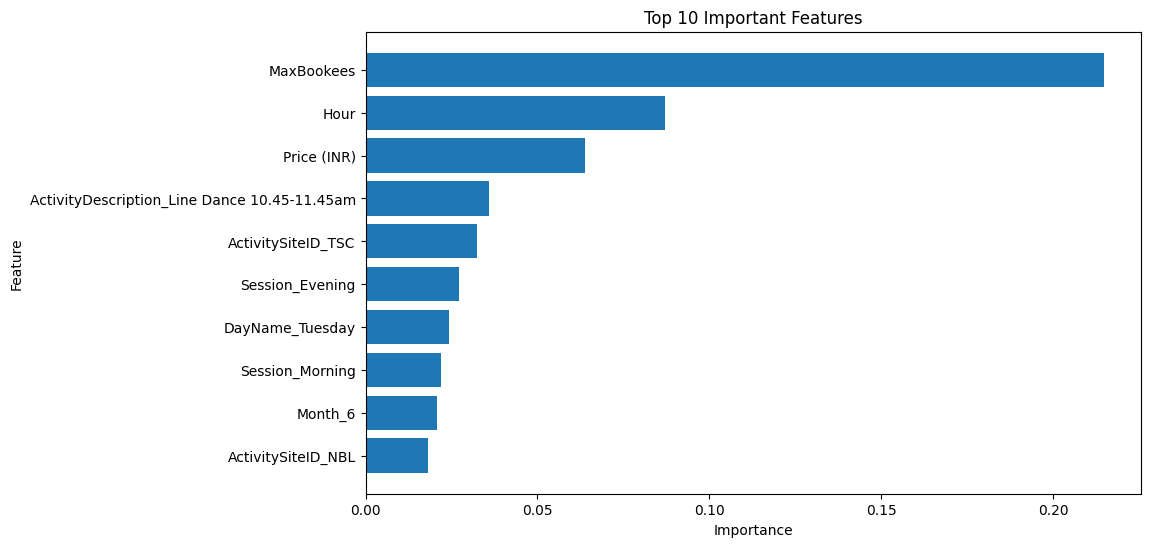

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Final Prediction Comparison

In [38]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best
})

comparison.head(10)

,Actual,Predicted
0,6,7.058677
1,15,10.765853
2,13,9.555520
3,9,8.343913
4,9,7.115684
5,23,25.116881
6,31,28.982520
7,10,7.279071
8,1,1.852337
9,7,6.156781


### Residual Plot

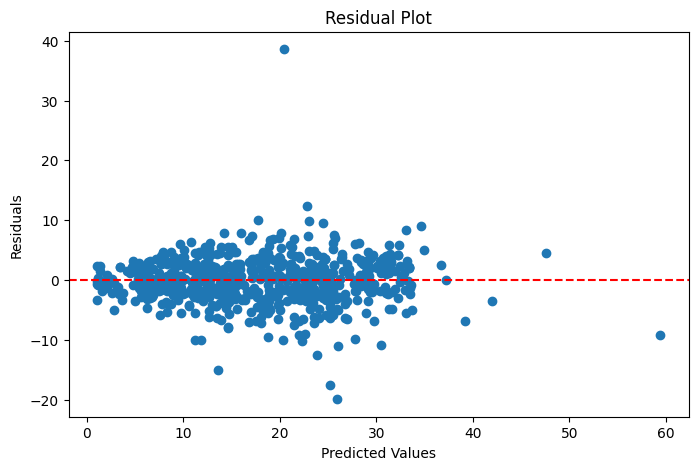

In [39]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

### Actual vs Predicted Plot

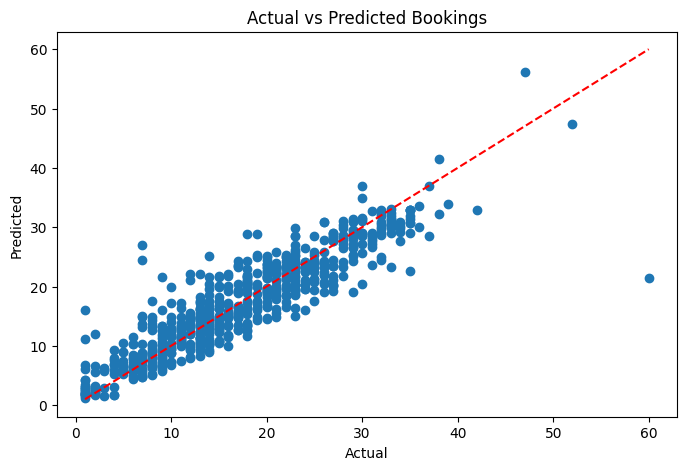

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_best)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.title("Actual vs Predicted Bookings")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()